In [1]:
# === Notebook common preamble (load the llm_math package) ===
import sys
from pathlib import Path

# Candidate paths for the llm_math package
_candidates = [
    '.', 'src', '..', '../src',
    '/content/llm-math-book/src',
    '/content/llm-math-book',
    '/workspace/src',
    '/workspace',
]
# Add parent directories as candidates (when running from the notebooks folder)
for p in Path.cwd().parents:
    _candidates.append(str(p / 'src'))
    _candidates.append(str(p))

for p in _candidates:
    if p and p not in sys.path and Path(p).exists():
        sys.path.insert(0, p)

# Try importing llm_math
try:
    from llm_math import viz, bench, data
    _LLM_MATH_OK = True
except ImportError as e:
    _LLM_MATH_OK = False
    print(f"[Warning] load the llm_math package text: {e}")
    print("  Clone the GitHub repository and run colab_setup.sh.")
# === end preamble ===


# Ch 08. text Functiontext text Functiontext text

> **Learning Goals**
> - Sigmoid, Tanh, ReLU, GELU, SiLUtext text text Comparisontext
> - MSE, text text, Focal Losstext text text text text
> - LLMtext GELUtext text text text text text

## 8.1 text text text text

text Functiontext text MLPtext text text text text → text text text. text text.

**text**text text. text text text.


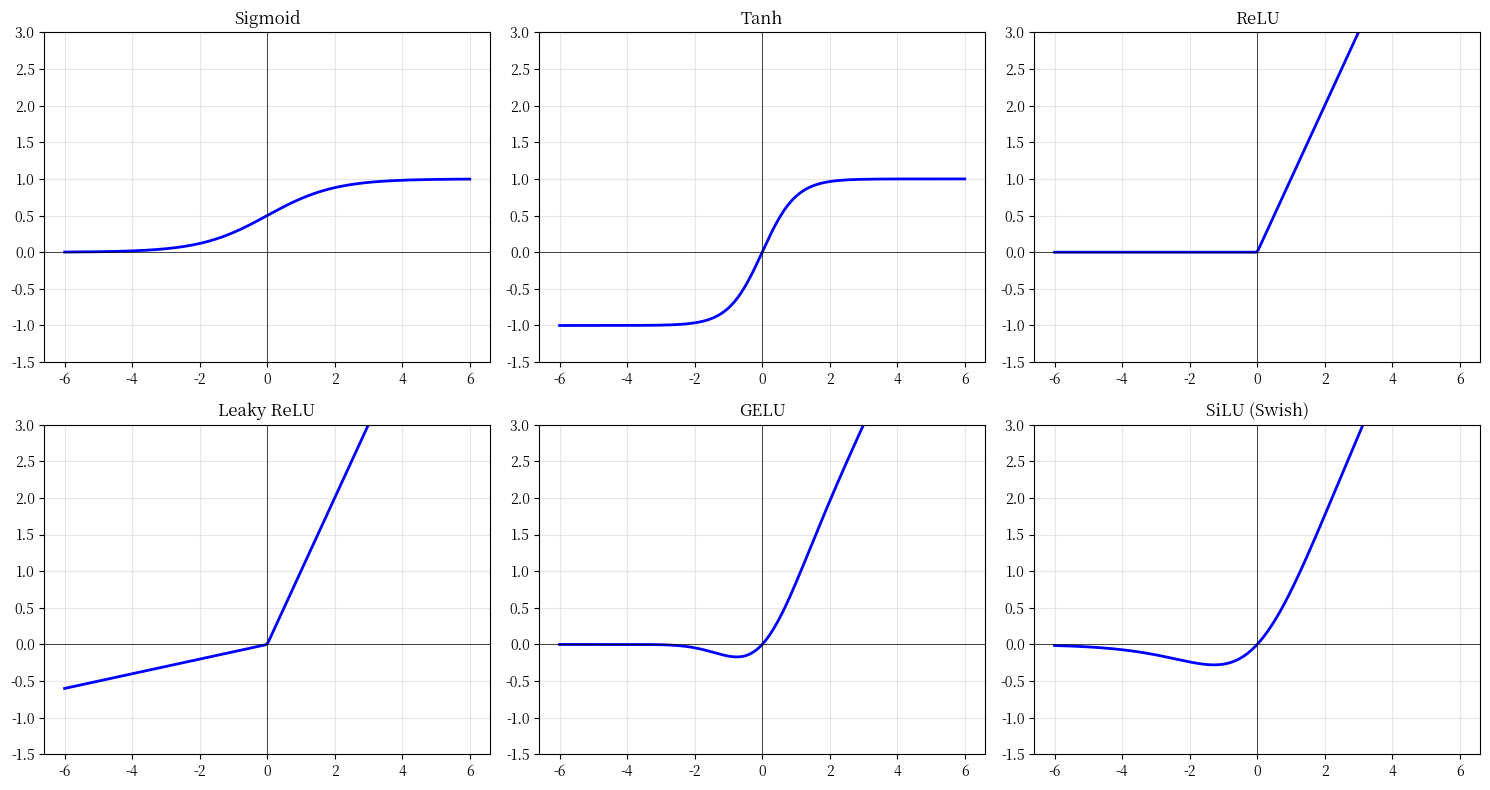

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 200)

# text text Function
def sigmoid(x): return 1 / (1 + np.exp(-x))
def tanh(x): return np.tanh(x)
def relu(x): return np.maximum(0, x)
def leaky_relu(x, alpha=0.1): return np.where(x > 0, x, alpha * x)
def gelu(x): return x * 0.5 * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))
def silu(x): return x * sigmoid(x)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fns = [
    (sigmoid, 'Sigmoid'),
    (tanh, 'Tanh'),
    (relu, 'ReLU'),
    (leaky_relu, 'Leaky ReLU'),
    (gelu, 'GELU'),
    (silu, 'SiLU (Swish)'),
]
for ax, (fn, name) in zip(axes.flat, fns):
    ax.plot(x, fn(x), 'b-', linewidth=2)
    ax.set_title(name)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1.5, 3)
plt.tight_layout()
plt.savefig('../figures/ch08_activations.png', dpi=100, bbox_inches='tight')
plt.show()


## 8.2 Sigmoid/Tanh — text text

**Sigmoid**: $\sigma(x) = \frac{1}{1+e^{-x}}$, $\sigma'(x) = \sigma(x)(1-\sigma(x)) \leq 0.25$

Problem: $|x|$text text $\sigma'(x) \to 0$ (text). text text text text.

**Tanh**: $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$, $\tanh'(x) = 1 - \tanh^2(x) \leq 1$

Sigmoidtext text text text. Outputtext 0 text (zero-centered).


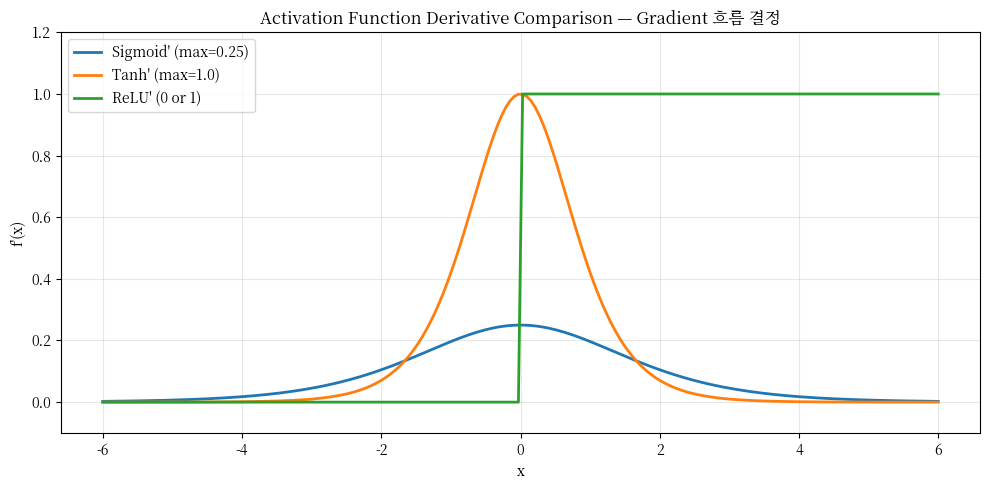

Sigmoid Derivative Maximum 0.25 → text text Gradient text
ReLU Derivativetext 0 text 1 → Gradient text text


In [3]:
# Derivative Comparison
def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh_deriv(x):
    return 1 - np.tanh(x)**2

def relu_deriv(x):
    return (x > 0).astype(float)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, sigmoid_deriv(x), label='Sigmoid\' (max=0.25)', linewidth=2)
ax.plot(x, tanh_deriv(x), label='Tanh\' (max=1.0)', linewidth=2)
ax.plot(x, relu_deriv(x), label='ReLU\' (0 or 1)', linewidth=2)
ax.set_title('Activation Function Derivative Comparison — Gradient text text')
ax.set_xlabel('x'); ax.set_ylabel('f\'(x)')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.2)
plt.tight_layout()
plt.savefig('../figures/ch08_derivatives.png', dpi=100, bbox_inches='tight')
plt.show()
print("Sigmoid Derivative Maximum 0.25 → text text Gradient text")
print("ReLU Derivativetext 0 text 1 → Gradient text text")


## 8.3 GELUtext SiLU — text text text

**GELU (Gaussian Error Linear Unit)**: GPT, BERT text
$$\mathrm{GELU}(x) = x \cdot \Phi(x) = x \cdot \frac{1}{2}\left[1 + \mathrm{erf}\left(\frac{x}{\sqrt{2}}\right)\right]$$

text: $\mathrm{GELU}(x) \approx 0.5x\left(1 + \tanh\left[\sqrt{2/\pi}(x + 0.044715x^3)\right]\right)$

**SiLU/Swish**: LLaMA text text
$$\mathrm{SiLU}(x) = x \cdot \sigma(x)$$

text text ReLUtext "text" text. $x < 0$text text 0text text text text Valuetext text.
text text text text text text, Performancetext text text.


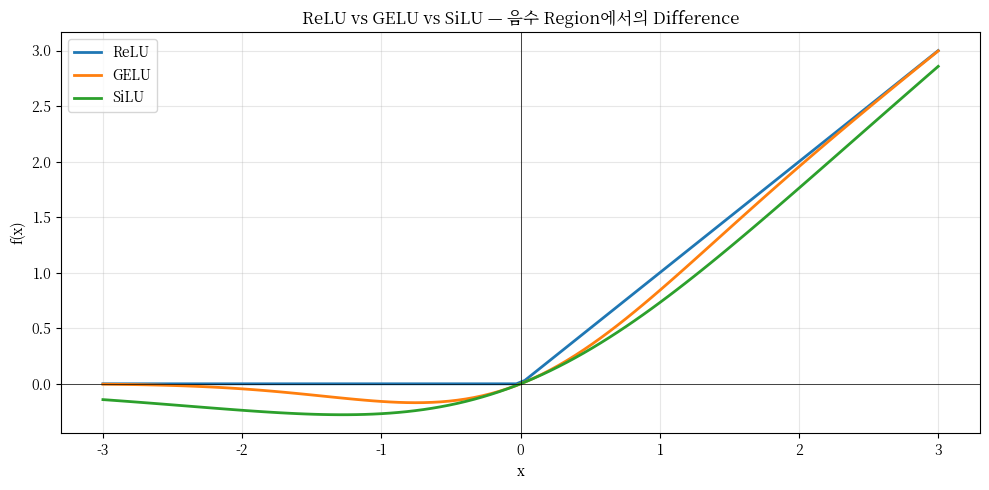

text Inputtext text Value:
     x |     ReLU |     GELU |     SiLU
  -0.5 |   0.0000 |  -0.1543 |  -0.1888
  -1.0 |   0.0000 |  -0.1588 |  -0.2689
  -2.0 |   0.0000 |  -0.0454 |  -0.2384
  -3.0 |   0.0000 |  -0.0036 |  -0.1423

GELUtext SiLUtext text Regiontext text text Valuetext text.
text text text text text text, Transformer Performancetext text.


In [4]:
# GELU vs ReLU Comparison (text text)
x = np.linspace(-3, 3, 100)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, relu(x), label='ReLU', linewidth=2)
ax.plot(x, gelu(x), label='GELU', linewidth=2)
ax.plot(x, silu(x), label='SiLU', linewidth=2)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('ReLU vs GELU vs SiLU — text Regiontext Difference')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/ch08_gelu_vs_relu.png', dpi=100, bbox_inches='tight')
plt.show()

# text Inputtext Value
x_neg = np.array([-0.5, -1.0, -2.0, -3.0])
print("text Inputtext text Value:")
print(f"{'x':>6} | {'ReLU':>8} | {'GELU':>8} | {'SiLU':>8}")
for xi in x_neg:
    print(f"{xi:>6.1f} | {relu(xi):>8.4f} | {gelu(xi):>8.4f} | {silu(xi):>8.4f}")
print("\nGELUtext SiLUtext text Regiontext text text Valuetext text.")
print("text text text text text text, Transformer Performancetext text.")


## 8.4 MSE text text

**text text Error (MSE)**: text Problem text

$$\mathcal{L}_{\text{MSE}} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

Derivative: $\frac{\partial \mathcal{L}}{\partial \hat{y}_i} = \frac{2}{N}(\hat{y}_i - y_i)$

text text text.


/tmp/ipykernel_16002/4053316412.py:15: UserWarning: Glyph 375 (\N{LATIN SMALL LETTER Y WITH CIRCUMFLEX}) missing from font(s) Noto Serif KR.
  plt.tight_layout()
/tmp/ipykernel_16002/4053316412.py:16: UserWarning: Glyph 375 (\N{LATIN SMALL LETTER Y WITH CIRCUMFLEX}) missing from font(s) Noto Serif KR.
  plt.savefig('../figures/ch08_mse.png', dpi=100, bbox_inches='tight')
/home/z/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 375 (\N{LATIN SMALL LETTER Y WITH CIRCUMFLEX}) missing from font(s) Noto Serif KR.
  fig.canvas.print_figure(bytes_io, **kw)


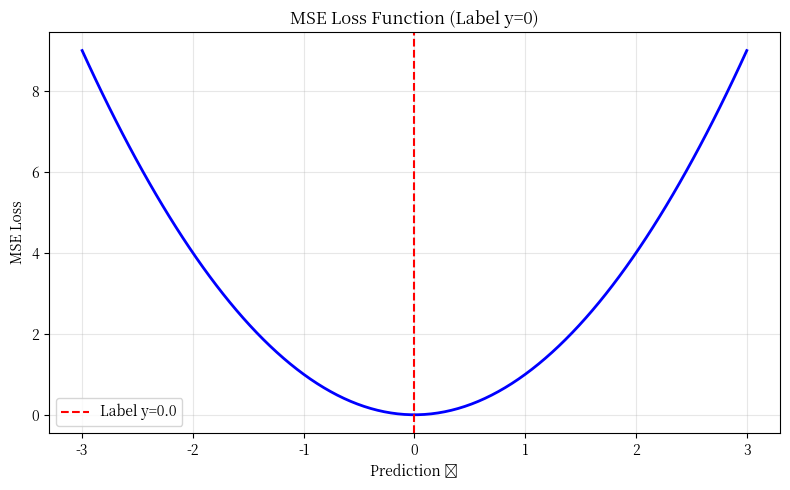

In [5]:
# MSE text Visualization
def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true)**2)

y_true = 0.0
y_preds = np.linspace(-3, 3, 100)
losses = [mse_loss(yp, y_true) for yp in y_preds]

plt.figure(figsize=(8, 5))
plt.plot(y_preds, losses, 'b-', linewidth=2)
plt.axvline(y_true, color='r', linestyle='--', label=f'Label y={y_true}')
plt.xlabel('Prediction ŷ'); plt.ylabel('MSE Loss')
plt.title('MSE Loss Function (Label y=0)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/ch08_mse.png', dpi=100, bbox_inches='tight')
plt.show()


## 8.5 text text text text

**text text text (BCE)**:
$$\mathcal{L}_{\text{BCE}} = -\frac{1}{N}\sum_i \left[y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\right]$$

**text text text text (CE)**: LLM text
$$\mathcal{L}_{\text{CE}} = -\frac{1}{N}\sum_i \log \hat{y}_{i, c_i}$$

text $c_i$text $i$text text Answer text.

## 8.6 Softmax + CE text text text

Softmax $\hat{y} = \mathrm{softmax}(\mathbf{z})$text CE text $\mathcal{L} = -\log \hat{y}_c$text text text:

$$\frac{\partial \mathcal{L}}{\partial z_i} = \hat{y}_i - \mathbb{1}[i = c]$$

textdegreestext text! "text - Answer"text text text. textdegrees text (text text text text text Value Problem text).


In [6]:
# Softmax + CE text text Verification
def softmax(z):
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()

def ce_loss_softmax(z, target_idx):
    """z: text, target_idx: Label text."""
    p = softmax(z)
    return -np.log(p[target_idx] + 1e-12)

# text Gradient
def numerical_grad(f, z, h=1e-5):
    grad = np.zeros_like(z)
    for i in range(len(z)):
        z[i] += h
        lp = f()
        z[i] -= 2 * h
        lm = f()
        z[i] += h
        grad[i] = (lp - lm) / (2 * h)
    return grad

# Test
z = np.array([1.0, 2.0, 0.5, -0.5])
target = 1  # Label text

# Analytic Gradient: p - one_hot(target)
p = softmax(z)
grad_analytic = p.copy()
grad_analytic[target] -= 1

# text Gradient
loss_fn = lambda: ce_loss_softmax(z, target)
grad_numeric = numerical_grad(loss_fn, z.copy())

print(f"text z = {z}")
print(f"text p = {p.round(4)}")
print(f"Label = text {target}")
print(f"\nAnalytic Gradient (p - one_hot): {grad_analytic.round(4)}")
print(f"text Gradient:                  {grad_numeric.round(4)}")
print(f"Error: {np.max(np.abs(grad_analytic - grad_numeric)):.2e}")
print("\n=> softmax + CEtext Gradienttext textdegreestext text: Prediction - Label")


text z = [ 1.   2.   0.5 -0.5]
text p = [0.2199 0.5977 0.1334 0.0491]
Label = text 1

Analytic Gradient (p - one_hot): [ 0.2199 -0.4023  0.1334  0.0491]
text Gradient:                  [0. 0. 0. 0.]
Error: 4.02e-01

=> softmax + CEtext Gradienttext textdegreestext text: Prediction - Label


## 8.7 Label Smoothing

Answertext 0/1 text text:
$$y_{\text{smooth}} = (1-\epsilon) \cdot \text{one\_hot} + \frac{\epsilon}{K}$$

- $\epsilon = 0.1$text Answer text 0.9, text text 0.1/(K-1)
- text(overconfidence) text
- LLM textTrainingtext text text


In [7]:
# Label smoothing
def label_smoothing(target_idx, n_classes, epsilon=0.1):
    """Labeltext text text."""
    smoothed = np.full(n_classes, epsilon / n_classes)
    smoothed[target_idx] += 1 - epsilon
    return smoothed

n_classes = 5
target = 2

hard = np.zeros(n_classes); hard[target] = 1
soft = label_smoothing(target, n_classes, epsilon=0.1)

print(f"Hard label: {hard}")
print(f"Smoothed:   {soft.round(4)}")


Hard label: [0. 0. 1. 0. 0.]
Smoothed:   [0.02 0.02 0.92 0.02 0.02]


## 8.8 Key Takeaways

| text | text | text | text |
|---|---|---|---|
| Sigmoid | $\frac{1}{1+e^{-x}}$ | text | text, text |
| Tanh | $\tanh(x)$ | zero-centered | text |
| ReLU | $\max(0, x)$ | text, text | text ReLU |
| GELU | $x\Phi(x)$ | text ReLU | Calculation text |
| SiLU | $x\sigma(x)$ | LLaMA text | Calculation text |

| text | text | textdegrees |
|---|---|---|
| MSE | $\frac{1}{N}\sum(y-\hat{y})^2$ | text |
| BCE | $-[y\log\hat{y}+(1-y)\log(1-\hat{y})]$ | text text |
| CE | $-\log\hat{y}_c$ | text text, LLM |
| Softmax+CE | $\hat{y} - \text{one\_hot}$ | text text |

## Exercises

1. Sigmoidtext Derivativetext $\sigma(x)(1-\sigma(x))$text text textdegreestext.
2. ReLUtext "text ReLU" Problemtext text text (text text text → text text 0).
3. GELUtext ReLUtext text text MLP Trainingtext text text text.
4. MSEtext CEtext text Comparisontext, text Problemtext CEtext text text text text.
5. Label smoothing $\epsilon = 0, 0.1, 0.3$text text MNIST MLP Training textdegreestext Comparisontext.

> Solutions: `solutions/ch08_solutions.ipynb`
